# Современные методы анализа данных и машинного обучения, БИ

## НИУ ВШЭ, 2025-26 учебный год

### Домашнее задание №2. Математическая статистика в анализе данных

Задание выполнил(а): Романцов Александр Николаевич

### Общая информация

__Дата выдачи:__ 23.03.2026

__Дедлайн:__ 04:00 02.04.2026

### Оценивание и штрафы

Каждое задание в рамках данного домашнего задания оценивается в 4 балла.

Оценка за домашнее задание вычисляется по следующей формуле:

$$
s_{\text{stat}} \times 1/2 ,
$$

где $s_{\text{stat}}$  — количество баллов, которое вы набрали в сумме по всем заданиям.

За сдачу домашнего задания позже срока на итоговую оценку за задание накладывается штраф в размере 1 **вторичный** балл в день, но  задержка не может быть больше недели.

__Внимание!__ Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов.

Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) допускается исключительно в рамках справочной и образовательной информации. Любые другие случаи применения средств ИИ — например, для автоматической генерации кода по заданию — считаются плагиатом, и такое домашнее задание оценивается в 0 баллов.

В случае если в решении используются подходы, функции или формулы, не разбиравшиеся на лекциях и семинарах, — необходимо обязательное указание источника: ссылка на документацию, статью, другой ресурс. При отсутствии оформления источников задание может быть полностью обнулено.

### Формат сдачи

Загрузка файлов с решениями происходит в системе [Anytask](https://anytask.org/). Необходимо загружать файл с расширением .ipynb (питоновский ноутбук)

Инвайт для подключения к странице курса в системе — указан для каждой группы в нашем телеграм-канале.

### О задании

В данном домашнем задании вы попрактикуетесь в применении методов математической статистики в анализе данных. Мы постарались подобрать для вас как можно более интересные и репрезентативные задания, максимально приближенные к тому, что реально используется при проведении A/B-тестирований и решении различных бизнес-задач в этой области.

В данном домашнем задании вам, вероятно, потребуется больше, чем обычно, осуществлять поиск информации как практического, так и теоретического характера, посредством чтения статей и различных материалов. Это ***нормально*** и лишь поможет вам глубже и качественнее, в понятном и комфортном для вас темпе, разобраться в непростом материале, связанном с математической статистикой в анализе данных.

Обратите внимание, что фактически во всех заданиях вам потребуется написать какой-то текст в виде вывода/результата/итога/какого-то резюме. Пожалуйста, не ленитесь, и пишите выводы ***подробно*** — существенная часть баллов будет выставляться именно за выводы, так как в анализе данных в целом, — а в разделе математической статистики — в особенности, — они имеют ключевое, наиболее заметное значение.
Текст выводов/комментариев пишите в отдельных ячейках, используя средства текстового редактора Jupyter Notebook/Google Colab, при необходимости используйте средства *выделения*. Написанные выводы подкрепляйте выполненным кодом программы.

При выполнении заданий данного домашнего задания нет абсолютно никаких ограничений на используемые библиотеки и применяемые вами методы, функционал.

### Задание 1

Проанализируйте набор данных и ответьте на следующие вопросы:

1) Какой процент наблюдений выходит за 5 и 95 перцентиль?

2) Какому закону распределения отвечают данные? На основе чего вы так решили?

[Ссылка на данные](https://drive.google.com/file/d/1fc8BGSjDiwbZW6rcr3mMSwAjU2T_BpGW/view?usp=sharing)

Описание данных:

* `metrics` — значение определенной метрики в сервисе для пользователя (например, количество кликов).

*Вместе с ответом на задание приложить код*

In [68]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [118]:
df = pd.read_csv("test_1_1.csv", sep=";")
print(df)
print(df.info())

        Unnamed: 0  metrics
0                1        1
1                2        1
2                3        4
3                4        1
4                5        1
...            ...      ...
306834      306835        8
306835      306836       11
306836      306837        1
306837      306838       81
306838      306839        1

[306839 rows x 2 columns]
<class 'pandas.DataFrame'>
RangeIndex: 306839 entries, 0 to 306838
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306839 non-null  int64
 1   metrics     306839 non-null  int64
dtypes: int64(2)
memory usage: 4.7 MB
None


In [70]:
np.percentile(df["metrics"], [5, 95])

array([ 1., 52.])

In [71]:
percent5, percent95 = (df["metrics"] < 1), (df["metrics"] > 52)
percent5, percent95 = percent5.mean() * 100, percent95.mean() * 100
print(percent5)
print(percent95)

0.0
4.987306046493438


In [72]:
df["metrics"].value_counts().sort_index()

metrics
1      132041
2       38880
3       21902
4       14785
5       10608
        ...  
500         1
501         1
626         1
628         1
998         1
Name: count, Length: 338, dtype: int64

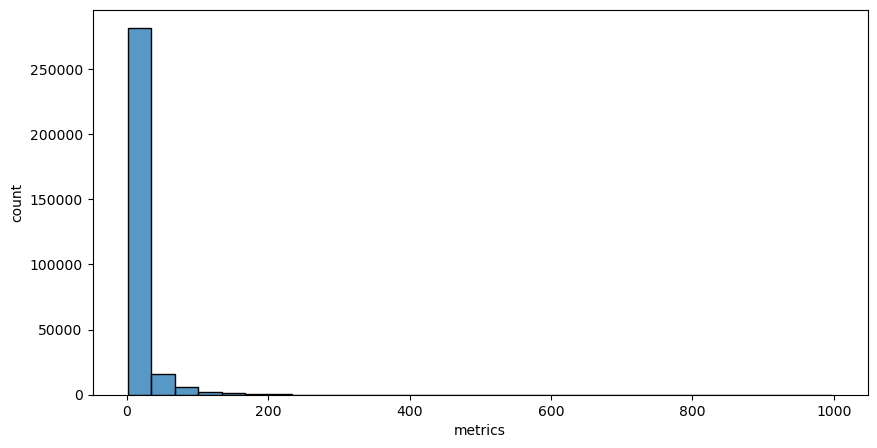

In [73]:
plt.figure(figsize=(10, 5))
sns.histplot(df["metrics"], bins=30)

plt.xlabel("metrics")
plt.ylabel("count")
plt.show()

In [74]:
print(df["metrics"].mean())
print(df["metrics"].var())

10.146275408276
511.9982326858158


In [171]:
import scipy.stats as stats

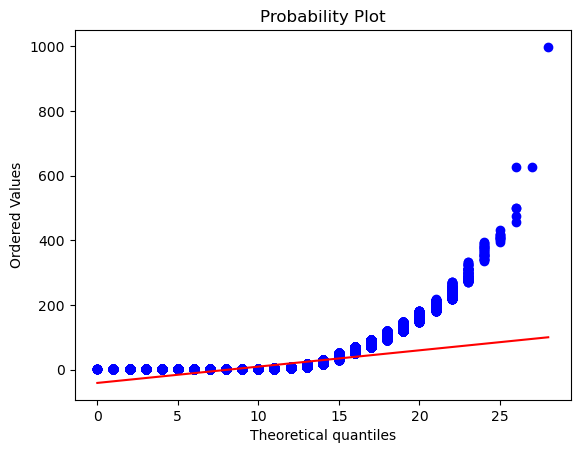

In [172]:
stats.probplot(df['metrics'], dist="poisson", sparams = (df["metrics"].mean(),), plot=plt)
plt.show()

Проверим на биномиальное распределение

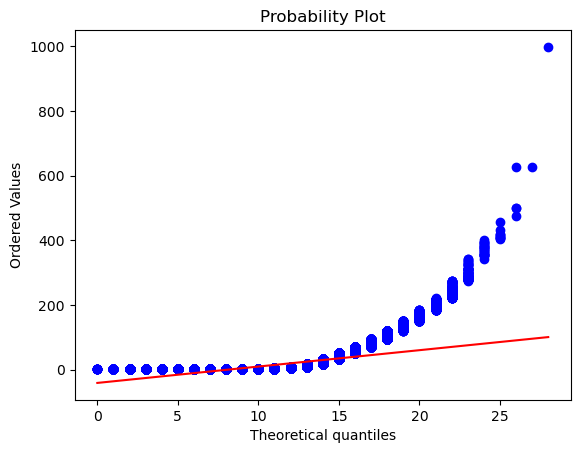

In [178]:
n= df['metrics'].max() #максимальное количество кликов в данных
p= df['metrics'].mean()/n #вероятность того, что в 1 испытает будет клик
stats.probplot(df['metrics'], dist="binom", sparams=(n, p), plot=plt)
plt.show()

Проверим на отрицательное биномиальное распределение

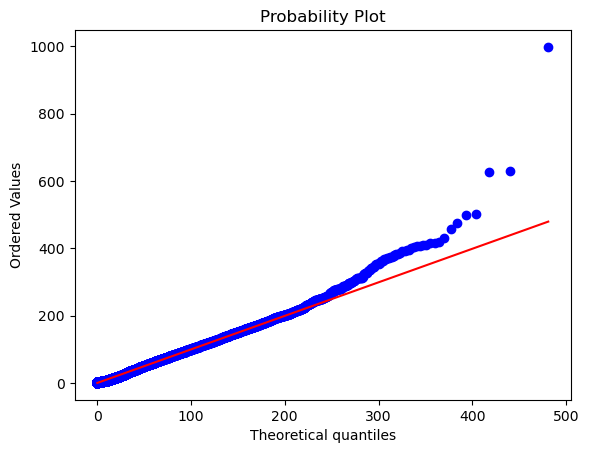

In [179]:
mean= df['metrics'].mean()
var= df['metrics'].var()
p= mean / var
n= (mean**2)/(var - mean)
stats.probplot(df['metrics'], dist="nbinom", sparams=(n, p), plot=plt)
plt.show()

Проверим на экспоненциальное распределение

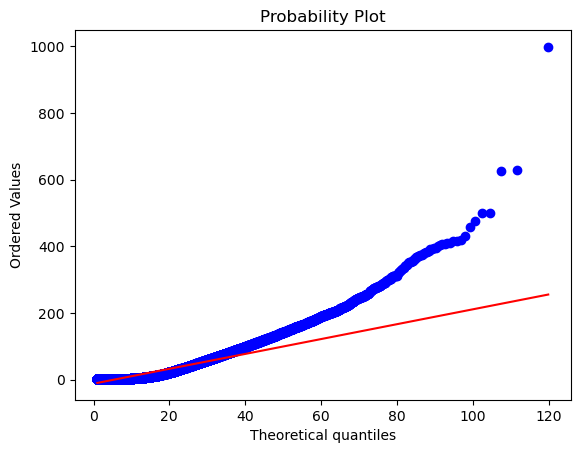

In [180]:
params = stats.expon.fit(df['metrics']) # мы должны сделать фит наших данных, чтобы получить параметры распределения
stats.probplot(df['metrics'], dist="expon", sparams=params, plot=plt)
plt.show()

Для отрицательного биномиального параметры находятся согласно формулам: https://ru.wikipedia.org/wiki/Отрицательное_биномиальное_распределение 

In [105]:
mean= df['metrics'].mean()
var= df['metrics'].var()
p= mean / var
n= (mean**2) / (var - mean)
print(n, p)

0.205134010474036 0.01981701256086599


1. За 5-ти процентный перцентиль выходит 0 процентов наблюдений. За 95-ти процентный перцентиль выходит примерно 4.99% наблюдей.
2. Датасет содержит целые числа, из чего следует, что распределение дискретное. Построил Ряд распределения и получается, что распределение похоже на Пуасоновское. Далее посчитал среднее и дисперсию, т.к дисперсия получилась сильно больше среднего - это не похоже на Пуассоновское распределение. Дополнительно посмотрел на QQ-plot он показывает насколько наши данные приближенны к какому-то распределению (в данном случае я проверил Пуассоновское). Как видно на графике у нас точно не распределение Пуассона. \

Я решил посмотреть какие бывают еще похожие на Пуассона распределения и проверить их на QQ-plot. Мне выдало 5 распределений из них одно было нормальное, но этот вариант нет смысла проверять исходя из первого графика распределения значений в начале ноутбука, также Гамма-распределение нам не подходит, так как оно для непрерывных величин, а у нас Дискретные. Поэтому осталось только 3: биномиальное, отрицательное биномиальное и экспоненциальное. По графикам QQ-plot можно сделать вывод, что обычное биномиальное нам не подходит, а также экспоненциальное. По графикам видно, что отрицательное биномиальное точнее всего описывают наши данные.

=> Наши данные описываются отрицательным биномиальным распределением с параметрами: 0.205134010474036 0.01981701256086599

### Задание 2

Определите, применим ли t-критерий Стьюдента для сравнения двух представленных выборок.

Если применение t-критерия Стьюдента возможно, выполните расчет.

Если сравнение с помощью t-критерия Стьюдента невозможно, укажите, какой критерий следует использовать вместо него, и обоснуйте свой выбор.

Ваши ответы аргументируйте.

[Ссылка на данные](https://drive.google.com/file/d/1blvC6TEBWghhVMexjOdoGEjzhZZh3wSy/view?usp=sharing)

Описание данных:

* `variant` — вариация в А/B тесте (например, группа А — сайт без изменений; группа B — сайт с изменениями)
* `metrics` — значение определенной метрики в сервисе для пользователя (например, количество кликов).

*Вместе с ответом на задание приложить код*

In [106]:
df2 = pd.read_csv('test2.csv', sep = ';')
df2

,Unnamed: 0,variant,metrics
0,1,A,1
1,2,B,1
2,3,A,4
3,4,B,37
4,5,B,4
...,...,...,...
184199,184200,A,12
184200,184201,A,8
184201,184202,B,11
184202,184203,B,81


In [107]:
a_group = df2[df2['variant'] == 'A']['metrics']
b_group = df2[df2['variant'] == 'B']['metrics']

Для того, чтобы понять можем ли мы применить t-тест, нам нужно проверить, что у нас выборки независимы (это выполнено по условиям), второе, что у нас данные распределены нормально и их дисперсии равны.

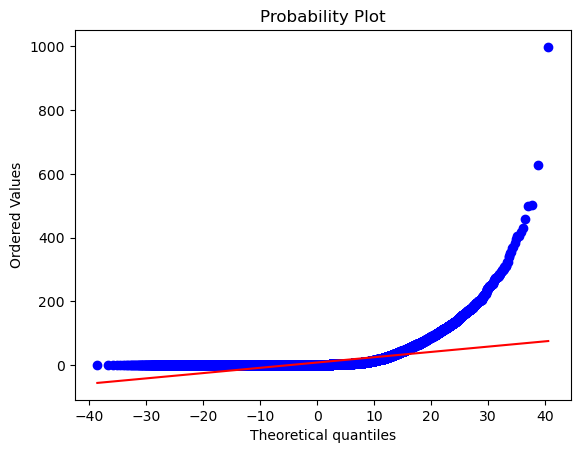

In [108]:
stats.probplot(a_group, dist="norm", sparams=params, plot=plt)
plt.show()

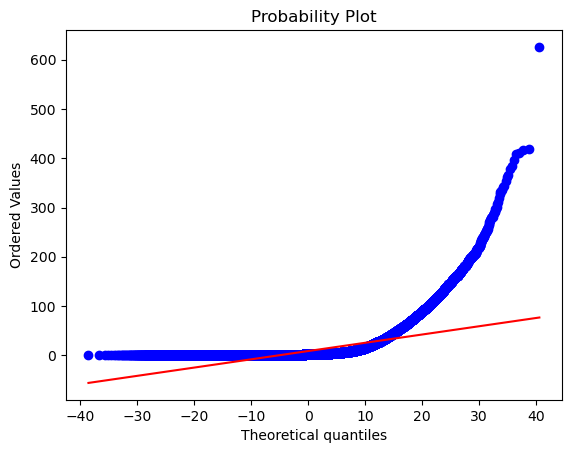

In [109]:
stats.probplot(b_group, dist="norm", sparams=params, plot=plt)
plt.show()

По графикам видно, что обе группы не имеют нормального распределения.

In [110]:
print(a_group.var(), b_group.var())

535.0037572661773 522.611376354044


Группы имеют между собой очень близкие дисперсии, но t-тест скорее нельзя применять из-за нарушения нормальности. Поэтому исходя из материалов семинара 9-10 с графиком использования тестов для проверки, получается, что нужно использовать не-параметрический тест Манна-Уитни. 

In [111]:
u, p = stats.mannwhitneyu(a_group, b_group, alternative = 'two-sided')
print(p)

2.7311182624546524e-05


Поскольку p_value < 0.05, то на 95% уровне значимости мы отвергаем нулевую гипотезу о том, что распределения одинаковые. Это означает, что различие между группами A и B статистически значимы, поэтому мы можем сделать вывод о том, что изменения на сайте действителньно повлияли на кол-во кликов.

### Задание 3

Вы работаете в стартапе, который разрабатывает приложение для грибников. Приложение с помощью компьютерного зрения определяет, съедобен ли гриб. Сейчас алгоритм работает правильно только в 50% случаев, то есть его точность не лучше случайного угадывания.

К вам приходит ML-инженер и заявляет, что улучшил алгоритм. Он просит премию и показывает результаты тестирования: на 120 грибах его новая модель дала правильный ответ в 79 случаях.

На основе этих данных вам необходимо:
1. Обосновать, стоит ли выплачивать инженеру премию, с помощью статистической проверки гипотез. Сформулируйте нулевую и альтернативную гипотезы, укажите используемый критерий, уровень значимости и сделайте вывод.
2. Определить, готова ли новая версия алгоритма к выпуску. Учтите не только статистическую значимость, но и практическую применимость.

Ваши ответы аргументируйте.

*Вместе с ответом на задание приложить код*

У нас 120 испытаний, результатом каждого является: 0 если гриб не распознан, 1 если гриб распознан. Соотвественно каждое испытание это бернулли. Число правильных ответов из 120 - это биномиальное распределение (из курса по ТВиМС все взял). Обозначим p - вероятность правильного ответа новой модели, p0 = 0,5 - старая точность. Пусть X - число правильных ответов новой модели из 120

1. H0: p=0.5 \
H1: p>0.5 \
Критерий: биномиальный тест \
Уровень значимости: 0.05 - стандартный. Далее во всех заданиях будет именнно этот уровень значимости.

Для вычисления p-value использована функция [scipy.stats.binomtest](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html) из документации SciPy

In [142]:
from scipy.stats import binomtest

In [151]:
n, k, p0 = 120, 79, 0.5

a = k / n
test = binomtest(k, n=n, p=p0, alternative='greater')

print(a)
print(test.pvalue)

0.6583333333333333
0.0003333619485017593


Наблюдаемая точность новой модели равна примерно 65.8%. p-value = 0.00033. Так как p-value < 0.05, то нулевая гипотеза отвергается на уровне значимости 5%. Следовательно, новая модель работает лучше случайного угадывания. С точки зрения статистической проверки гипотез инженеру можно выплачивать премию


In [144]:
120-79

41

2. Да, улучшение статистически значимо, но, на практике, точность все еще низкая. Модель ошиблась в 41 случаях из 120 . Соответсвенно человек, опираясь на данную модель может съесть гриб и отравиться, чего допустить нельзя. Максимум модель жизнеспособна как исследовательский прототип или вспомогательный инструмент.

### Задание 4

Перед вами представлен датасет `Employee_satisfaction.csv`, содержащий следующую информацию:

[Ссылка на данные](https://drive.google.com/file/d/1XSuJH8vy6KFICYAkRc7qMvPrMKO2lZ6o/view?usp=sharing)

Описание данных:

* `Emp ID` - порядковый номер сотрудника
* `satisfaction_level` - самооценка уровня удовлетворенности работой
* `last_evaluation` - оценка на последнем перформанс-ревью
* `number_project` - количество проектов, над которыми работает сотрудник
* `average_montly_hours` - среднее количество часов, отработанных сотрудником в месяц
* `time_spend_company` - количество лет, которые сотрудник работает в компании
* `Work_accident` - попадал ли сотрудник в какой-то инцидент на работе (1 - да, 0 - нет)
* `promotion_last_5years` - получал ли сотрудник повышение за последние 5 лет (1 - да, 0 - нет)
* `dept` - отдел, где работает сотрудник
* `salary` - уровень зарплаты сотрудника (e.g., low, medium)

Очистите данные от пропущенных значений. Проанализировав взаимосвязь уровня удовлетворенности работой с остальными признаками, ответьте на следующие вопросы:
1. Есть ли какая-то статистически значимая связь между удовлетворенностью и оценкой на ревью?
2. Есть ли какая-то статистически значимая связь между удовлетворенностью и зарплатой? При ответе на вопрос сформируйте из переменной `salary` новую переменную, содержащую два значения: низкую зарплату `low` и все остальные
3. Есть ли связь между удовлетворенностью работой и средним количеством рабочих часов в месяц?

Дайте развернутые ответы с указанием результата, описанием вывода и способом его получения.

*Вместе с ответом на задание приложить код*

In [145]:
df3 = pd.read_csv('Employee_satisfaction.csv', sep = ',')
df3

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low
...,...,...,...,...,...,...,...,...,...,...
15782,14995.0,0.40,0.57,2.0,151.0,3.0,0.0,0.0,support,low
15783,14996.0,0.37,0.48,2.0,160.0,3.0,0.0,0.0,support,low
15784,14997.0,0.37,0.53,2.0,143.0,3.0,0.0,0.0,support,low
15785,14998.0,0.11,0.96,6.0,280.0,4.0,0.0,0.0,support,low


In [146]:
print(df3.info())
print(df3.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 15787 entries, 0 to 15786
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp ID                 14999 non-null  float64
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  float64
 4   average_montly_hours   14999 non-null  float64
 5   time_spend_company     14999 non-null  float64
 6   Work_accident          14999 non-null  float64
 7   promotion_last_5years  14999 non-null  float64
 8   dept                   14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(8), str(2)
memory usage: 1.2 MB
None
Emp ID                   788
satisfaction_level       788
last_evaluation          788
number_project           788
average_montly_hours     788
time_spend_company       788
Work_accident            788
promotion_last_5years 

In [147]:
df3 = df3.dropna()
print(df3.isna().sum())
print(df3.shape)
print(df3.duplicated().sum())

Emp ID                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
dept                     0
salary                   0
dtype: int64
(14999, 10)
0


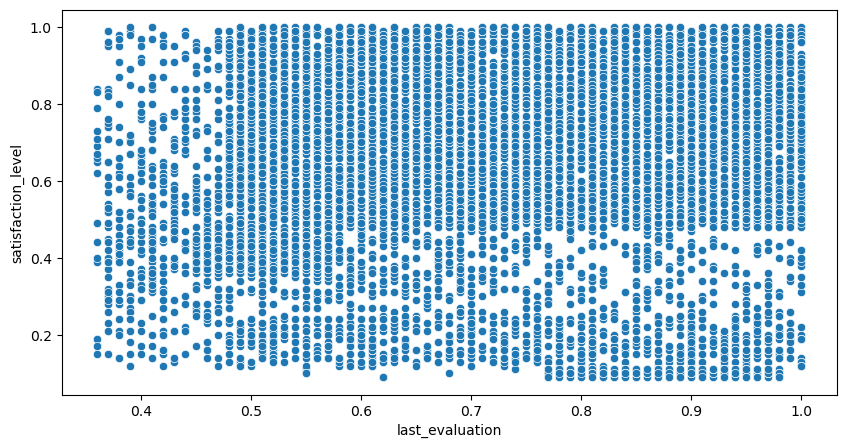

In [148]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df3, x="last_evaluation", y="satisfaction_level")
plt.xlabel("last_evaluation")
plt.ylabel("satisfaction_level")
plt.show()

По диаграмме рассеяния не наблюдается явной линейной зависимости между уровнем удовлетворенности и оценкой на ревью. Поэтому далее проверим наличие связи с помощью коэффициента корреляции.

Для вычисления коэффициента корреляции использована функция [scipy.stats.pearsonr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) из документации SciPy

In [150]:
from scipy.stats import pearsonr

In [152]:
corr, p_value = pearsonr(df3["last_evaluation"], df3["satisfaction_level"])
print(corr)
print(p_value)

0.10502121397148488
4.7043115582916e-38


1. Между satisfaction_level и last_evaluation наблюдается слабая положительная связь. Коэф. корреляции Пирсона равен 0.105. При этом p-value значительно меньше 0.05 => связь статистически значима. Т.е зависимость между удовлетворенностью работой и оценкой на ревью есть, но выражена она слабо.


In [155]:
df3["salary_group"] = df3["salary"].apply(lambda x: "low" if x == "low" else "other")
print(df3["salary_group"].value_counts())

salary_group
other    7683
low      7316
Name: count, dtype: int64


In [156]:
low_group = df3[df3["salary_group"] == "low"]["satisfaction_level"]
other_group = df3[df3["salary_group"] == "other"]["satisfaction_level"]

print(low_group.describe())
print(other_group.describe())

count    7316.000000
mean        0.600753
std         0.254594
min         0.090000
25%         0.420000
50%         0.630000
75%         0.810000
max         1.000000
Name: satisfaction_level, dtype: float64
count    7683.000000
mean        0.624337
std         0.242274
min         0.090000
25%         0.480000
50%         0.660000
75%         0.820000
max         1.000000
Name: satisfaction_level, dtype: float64


После разделения сотрудников на группы low и other оказалось, что среднее и медианное значение satisfaction_level в группе low ниже, чем в группе other. Это может говорить о том, что сотрудники с низкой зарплатой в среднем менее удовлетворены своей работой. Далее проверим, является ли эта разница статистически значимой

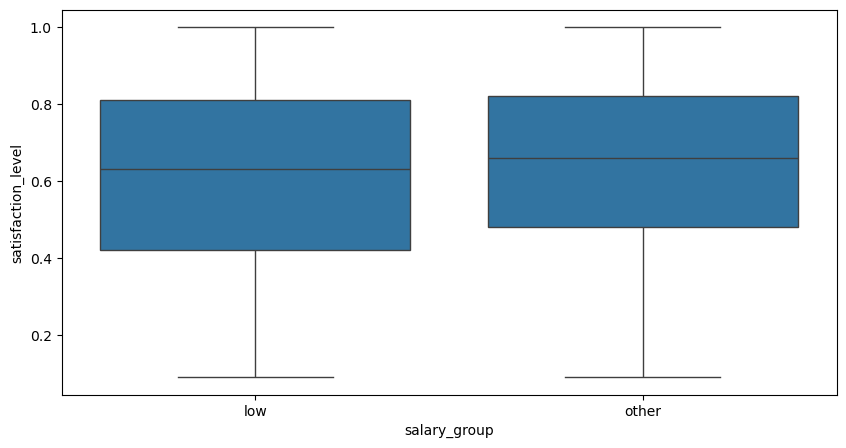

In [157]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df3, x="salary_group", y="satisfaction_level")
plt.xlabel("salary_group")
plt.ylabel("satisfaction_level")
plt.show()

Объяснение и примеры использования критерия Манна-Уитни представлены в семинарах 9-10

In [161]:
from scipy.stats import mannwhitneyu

In [159]:
stat, p_value = mannwhitneyu(low_group, other_group, alternative="two-sided")
print(stat)
print(p_value)

26690781.0
9.628310958572507e-08


2. Для сравнения уровня удовлетворенности в двух независимых группах сотрудников (low и other) был использован критерий Манна-Уитни, так как он подходит для сравнения двух независимых выборок без предположения о нормальности распределения.

    По boxplot и описательным статистикам уже видно, что у сотрудников с низкой зарплатой удовлетворенность немного ниже. Результат теста это подтверждает: p-value значительно меньше 0.05 => между уровнем удовлетворенности работой и зарплатой есть статистически значимая связь и сотрудники с низкой зарплатой в среднем менее удовлетворены своей работой чем остальные.

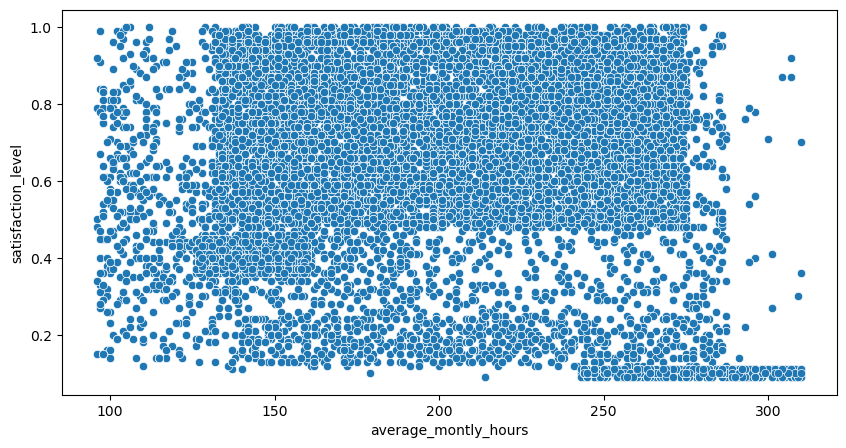

In [163]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df3, x="average_montly_hours", y="satisfaction_level")
plt.xlabel("average_montly_hours")
plt.ylabel("satisfaction_level")
plt.show()

Так как переменные числовые, но по графику не видно явной линейной зависимости, для анализа связи используем коэффициент Спирмена.
Для вычисления p-value использована функция [scipy.stats.spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) из документации SciPy.

In [164]:
from scipy.stats import spearmanr

In [165]:
corr, p_value = spearmanr(df3["average_montly_hours"], df3["satisfaction_level"])
print(corr)
print(p_value)

0.06199958683277002
2.96604328275535e-14


3. Коэффициент корреляции = 0.062, что указывает на очень слабую положительную связь между переменными. При этом p-value значительно меньше 0.05, из-за этого связь можно считать статистически значимой => между уровнем удовлетворенности работой и средним количеством рабочих часов в месяц есть статистически значимая, но очень слабая положительная связь.

### Задание 5

В компании решили ввести новую систему обучения для сотрудников и оценить ее эффективность с помощью A/B-теста. Результаты представлены в датасете `hr_ab_test_dataset.csv`.

[Ссылка на данные](https://drive.google.com/file/d/1DYGyX1IpOrczc1dJ4g98lybPXL3oWnN5/view?usp=sharing)

Описание данных:

* `Group` - группа A (сотрудники, прошедшие обучение), группа B (сотрудники, не прошедшие обучение).
* `Age` - возраст сотрудника.
* `Performance score` - метрика "Оценка производительности".

Гипотеза - обучение положительно влияет на оценку производительности.

На основе анализа результатов теста определите, какая из групп (A или B) продемонстрировала лучшие результаты. Какие статистические методы (критерии) вы использовали для принятия этого решения? Сформулируйте выводы относительно эффективности новой системы обучения, а также установите, существует ли связь между достигнутыми результатами и возрастом участников. Ответ аргументируйте.

*Вместе с ответом на задание приложить код*

In [166]:
df4 = pd.read_csv('hr_ab_test_dataset.csv', sep = ',')
df4

,Group,Age,Performance score
0,A,21,4.248357
1,A,45,3.930868
2,A,36,4.323844
3,A,59,4.761515
4,A,52,3.882923
...,...,...,...
195,B,50,3.192659
196,B,24,2.558071
197,B,54,3.076863
198,B,42,3.029104


In [168]:
print(df4.shape)
print(df4.info())
print(df4.isna().sum())
print(df4.duplicated().sum())

(200, 3)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Group              200 non-null    str    
 1   Age                200 non-null    int64  
 2   Performance score  200 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 4.8 KB
None
Group                0
Age                  0
Performance score    0
dtype: int64
0


In [169]:
group_A = df4[df4["Group"] == "A"]["Performance score"]
group_B = df4[df4["Group"] == "B"]["Performance score"]

print(group_A.describe())
print(group_B.describe())

count    100.000000
mean       3.948077
std        0.454084
min        2.690127
25%        3.699547
50%        3.936522
75%        4.202976
max        4.926139
Name: Performance score, dtype: float64
count    100.000000
mean       3.011152
std        0.476834
min        2.040614
25%        2.597170
50%        3.042054
75%        3.269085
max        4.360085
Name: Performance score, dtype: float64


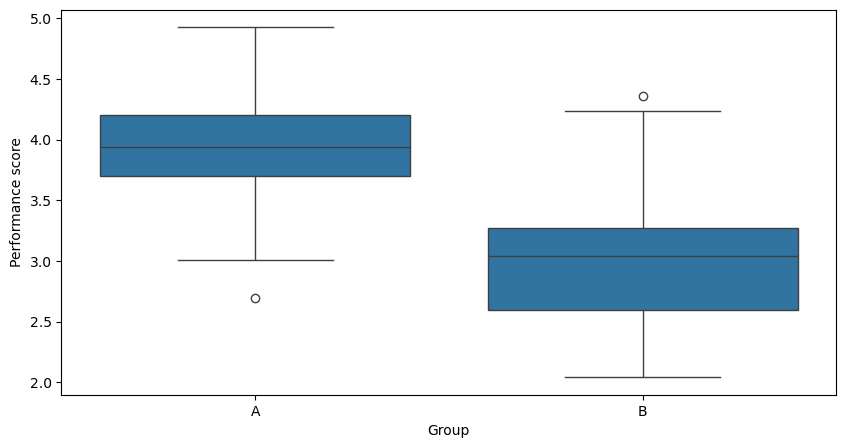

In [170]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df4, x="Group", y="Performance score")
plt.xlabel("Group")
plt.ylabel("Performance score")
plt.show()

И по описательным статистикам, и по boxplot видно, что группа A показывает более высокие значения Performance score чем группа B. Это позволяет предположить положительный эффект обучения. 

Далее нужно понять, можно ли сравнивать группы с помощью параметрического теста. Для этого сначала проверим, насколько распределение Performance score в группах A и B похоже на нормальное, с помощью критерия Шапиро-Уилка. Если нормальность не подтвердится, будем использовать критерий Манна-Уитни (такой порядок действий разбирался в семинаре 9–10)

In [173]:
from scipy.stats import shapiro

In [174]:
print(shapiro(group_A))
print(shapiro(group_B))

ShapiroResult(statistic=np.float64(0.9898833815158512), pvalue=np.float64(0.6551676754214469))
ShapiroResult(statistic=np.float64(0.9775339933952859), pvalue=np.float64(0.08525602813445946))


По критерию Шапиро-Уилка в обеих группах p-value больше 0.05, поэтому оснований отвергать гипотезу о нормальности нет => распределение Performance score в группах A и B можно считать достаточно близким к нормальному, и далее для сравнения групп используем t-test для независимых выборок.

В условии уже дана содержательная гипотеза о том, что обучение положительно влияет на оценку производительности. Для статистической проверки переведем ее в нужный вид: \
H0: средний Performance score в группе A не выше, чем в B \
H1: средний Performance score в группе A выше, чем в B 

In [175]:
from scipy.stats import ttest_ind

In [176]:
stat, p_value = ttest_ind(group_A, group_B, equal_var=False, alternative="greater")
print(stat)
print(p_value)

14.229124055211921
2.1593166540469498e-32


В результате t-теста (для независимых выборок) p-value значительно меньше 0.05 => нулевая гипотеза отвергается, и есть статистически значимые основания считать, что средний Performance score в группе A выше, чем в группе B => новая система обучения действительно положительно повлияла на результаты сотрудников

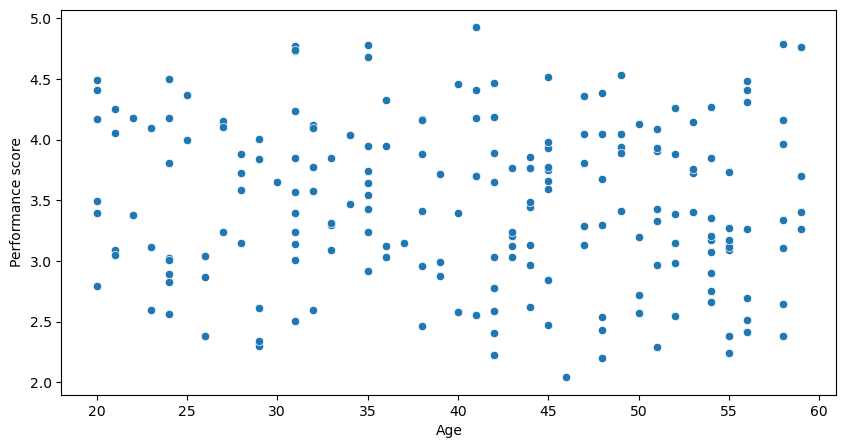

In [177]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df4, x="Age", y="Performance score")
plt.xlabel("Age")
plt.ylabel("Performance score")
plt.show()

По диаграмме рассеяния не видно явной линейной зависимости между возрастом и Performance score, поэтому далее проверим связь количественно с помощью коэффициента Спирмена.

[scipy.stats.spearmanr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) из документации SciPy

In [182]:
from scipy.stats import spearmanr

In [183]:
corr, p_value = spearmanr(df4["Age"], df4["Performance score"])
print(corr)
print(p_value)

-0.08474888015332586
0.23280454499075903


Коэффициент корреляции Спирмена между Age и Performance score = примерно -0.085, что указывает на очень слабую отрицательную связь между переменными. При этом p-value равен примерно 0.233, т.е больше 0.05. Следовательно, статистически значимой связи между возрастом сотрудников и достигнутыми результатами в данном датасете не обнаружено.

По итогам анализа группа A показала лучшие результаты, чем группа B. t-тест подтвердил, что эта разница статистически значима => новая система обучения действительно положительно повлияла на Performance score. При этом статистически значимой связи между возрастом сотрудников и их результатами обнаружено не было.